# Google Drive への接続

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 回帰分析の実行

### ライブラリのインポート

In [36]:
import pandas as pd
import statsmodels.formula.api as smf
import japanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

### データの読み込み

In [31]:
path = '/content/drive/MyDrive/DS_seminar/prefecture_data_2022.xlsx'
df = pd.read_excel(path, sheet_name = 'data', dtype = {'area_code': str})
df.head()

,area_code,prefecture,pop,nursery,land_price,tfr,pref_income
0,R01000,北海道,5140000,1099,22000,1.12,14862720
1,R02000,青森県,1204000,472,15900,1.24,3256529
2,R03000,岩手県,1181000,391,25600,1.21,3197720
3,R04000,宮城県,2280000,515,46000,1.09,6546469
4,R05000,秋田県,930000,268,13200,1.18,2575304


### 基本統計量の出力

In [32]:
df.describe()

,pop,nursery,land_price,tfr,pref_income
count,4.700000e+01,47.000000,47.000000,47.000000,4.700000e+01
mean,2.658426e+06,645.872340,53372.340426,1.358298,9.165928e+06
std,2.793536e+06,616.451367,61991.621812,0.149366,1.347645e+07
min,5.440000e+05,187.000000,13200.000000,1.040000,1.354064e+06
25%,1.046500e+06,299.000000,25300.000000,1.245000,3.147550e+06
50%,1.563000e+06,439.000000,30800.000000,1.360000,4.638642e+06
75%,2.655000e+06,662.000000,55500.000000,1.455000,8.507552e+06
max,1.403800e+07,3615.000000,389100.000000,1.700000,8.474560e+07


### 単回帰分析

**人口を1000人単位に変換（係数を解釈しやすくするため）**

In [33]:
df['pop_thousand'] = df['pop'] / 1000

**回帰モデル**

In [34]:
model = smf.ols('nursery ~ pop_thousand', data = df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                nursery   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     948.7
Date:                Wed, 13 May 2026   Prob (F-statistic):           6.94e-32
Time:                        08:17:31   Log-Likelihood:                -295.38
No. Observations:                  47   AIC:                             594.8
Df Residuals:                      45   BIC:                             598.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       72.6726     26.844      2.707   

### 重回帰分析

In [35]:
model2 = smf.ols('nursery ~ pop_thousand + tfr', data = df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                nursery   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     507.7
Date:                Wed, 13 May 2026   Prob (F-statistic):           4.03e-31
Time:                        08:19:46   Log-Likelihood:                -293.35
No. Observations:                  47   AIC:                             592.7
Df Residuals:                      44   BIC:                             598.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     -372.6597    224.924     -1.657   

### 散布図と回帰直線

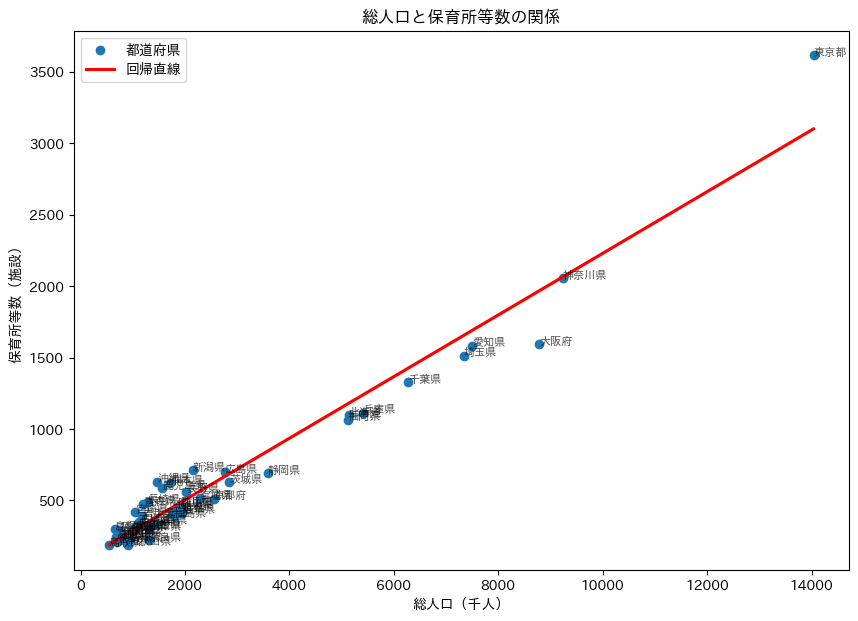

In [ ]:
# 描画領域を作成（幅10×高さ7）
fig, ax = plt.subplots(figsize=(10, 7))

# 散布図をプロット（x=人口，y=保育所等数）
ax.scatter(df['pop_thousand'], df['nursery'], label='都道府県')

# 各都道府県のラベルを表示
for i, row in df.iterrows():
    ax.annotate(row['prefecture'], (row['pop_thousand'], row['nursery']), fontsize=8, alpha=0.7)

# 回帰直線をプロット（seaborn の regplot を使用，散布図は描かず線だけ）
sns.regplot(x='pop_thousand', y='nursery', data=df, ax=ax, scatter=False, ci=None, line_kws={'color' : 'red'})

# regplot で描いた赤線のラベルを上書き（凡例に表示させるため）
ax.lines[-1].set_label('回帰直線')

# 軸ラベルとタイトルを設定
ax.set_xlabel('総人口（千人）')
ax.set_ylabel('保育所等数（施設）')
ax.set_title('総人口と保育所等数の関係')

# 凡例を表示
ax.legend(loc='upper left')

# グラフを表示
plt.show()